# Fast-Fire Days Analysis for Tribal Lands
**Series:** Tribal Fire Science & Indigenous Data Sovereignty  
**Author:** Lilly Jones, PhD  
**Last Updated:** 2025  
**Data Sources:** gridMET (University of Idaho), Census TIGER AIANNH

## Overview
Fast-fire weather conditions are beyond Tribal control, yet they determine fire risk
and response capacity. This notebook identifies and trends Fast-Fire-Conducive Days or
days when meteorological conditions combine to create potential for extreme fire behavior.
Weather data comes from gridMET, a high-resolution (4km) daily surface meteorological
dataset covering CONUS from 1979 to present.

## Research Questions
- How many fast-fire-conducive days occur annually on each Tribal land unit?
- Are fast-fire day frequencies trending upward over time?
- Which months concentrate the highest fast-fire risk, and is that shifting?
- What multi-day episodes represent the greatest sustained danger?

## Outputs
- Annual fast-fire day counts per Tribal land (2000–2024)
- Multi-decadal trends and change detection
- Seasonal patterns and timing shifts
- Extreme event frequency analysis

## Data Sovereignty Note
> Tribal boundary data comes from Census TIGER AIANNH federal statistical boundaries
> that may not reflect Tribal Nations' own definitions of territory.
> See the acknowledgment below. All weather data is real; no synthetic data is used.

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Import modules 
from src.data import constants, loaders, validators
from src.geo import utils as geo_utils
from src.indigenous.sovereignty import (
    generate_citations,
    print_data_acknowledgment,
)
from src.viz import charts, styles

styles.apply_mpl_style()
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print(f"Repo root : {REPO_ROOT}")
print(f"Cache dir : {constants.CACHE_DIR}")
print(f"Output dir: {constants.OUTPUTS_DIR}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\tfs_refactor
Cache dir : C:\Users\gekek\Documents\tfs_refactor\data\cache
Output dir: C:\Users\gekek\Documents\tfs_refactor\outputs
Analysis run: 2026-04-06 10:31


In [2]:
# Data sovereignty acknowledgment 
print_data_acknowledgment(source_keys=["census_aiannh", "gridmet"])

DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and fire histories. This project is guided by three
complementary data governance frameworks:

OCAP®: Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE: Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR: Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

Tribal Nations are sovereign governments with the right to control data about their own communities and territories.
Federal and third-pa

## Configure Fast-Fire Day Criteria

In [3]:
# Fast-Fire Day Thresholds 
# Based on fire behavior research and NFDRS operational experience.
# All criteria must be met simultaneously for a day to be classified as
# fast-fire-conducive.

FIRE_WEATHER_THRESHOLDS = {
    "wind_mph": {
        "moderate": 15,   # Increased fire activity
        "high":     25,   # Rapid fire spread
        "extreme":  35,   # Extreme fire behavior
    },
    "rh_pct": {
        "moderate": 25,   # Fuels receptive to ignition
        "high":     15,   # Very dry fuels
        "extreme":  10,   # Critically dry
    },
    "temp_f": {
        "moderate": 80,   # Elevated fire danger
        "high":     90,   # High fire danger
        "extreme":  100,  # Extreme conditions
    },
    "burning_index": {
        "moderate": 50,
        "high":     75,
        "extreme":  100,
    },
}

ANALYSIS_CONFIG = {
    "start_year":           2000,
    "end_year":             2024,
    "fire_season_months":   [5, 6, 7, 8, 9, 10],   # May–October
    "threshold_level":      "high",                  # 'moderate', 'high', or 'extreme'
}

# References to active thresholds
T = ANALYSIS_CONFIG["threshold_level"]
WIND_THRESH = FIRE_WEATHER_THRESHOLDS["wind_mph"][T]
RH_THRESH   = FIRE_WEATHER_THRESHOLDS["rh_pct"][T]
TEMP_THRESH = FIRE_WEATHER_THRESHOLDS["temp_f"][T]
BI_THRESH   = FIRE_WEATHER_THRESHOLDS["burning_index"][T]

print(f"Fast-Fire Day Criteria ({T.upper()} threshold level)")
print(f"  Wind Speed     : >= {WIND_THRESH} mph")
print(f"  Relative Humidity : <= {RH_THRESH}%")
print(f"  Temperature    : >= {TEMP_THRESH}°F")
print(f"  Burning Index  : >= {BI_THRESH}")
print(f"\nFire Season    : months {ANALYSIS_CONFIG['fire_season_months']}")
print(f"Analysis Period: {ANALYSIS_CONFIG['start_year']}–{ANALYSIS_CONFIG['end_year']}")

Fast-Fire Day Criteria (HIGH threshold level)
  Wind Speed     : >= 25 mph
  Relative Humidity : <= 15%
  Temperature    : >= 90°F
  Burning Index  : >= 75

Fire Season    : months [5, 6, 7, 8, 9, 10]
Analysis Period: 2000–2024


## Load Tribal Land Boundaries

In [4]:
# Census TIGER AIANNH 
all_tribal = loaders.load_census_aian()
all_tribal = validators.validate_geodataframe(
    all_tribal,
    dataset_name="census_aiannh",
    required_columns=["geometry", "NAME"],
)
print(f"Total AIANNH areas in Census dataset: {len(all_tribal):,}")

# Filter to Tribal lands of interest 
# Edit this list to analyze different Tribal Nations.
# Names must match the 'NAME' column in the Census TIGER dataset.
# Run all_tribal['NAME'].sort_values().tolist() to see all available names.

TRIBES_OF_INTEREST = [
    "Choctaw",
    "Osage",
    "Creek",
    "San Carlos",
    "Fort Apache",
    "Cherokee",
    "Kiowa-Comanche-Apache-Fort Sill Apache",
    "Chickasaw",
    "Colville",
    "Warm Springs",
]

tribal_lands = all_tribal[
    all_tribal["NAME"].isin(TRIBES_OF_INTEREST)
].copy().reset_index(drop=True)

if tribal_lands.empty:
    print("\nNo matching Tribal lands found. Check spelling against Census NAME field.")
    print("Available names containing 'Apache':")
    print(all_tribal[all_tribal["NAME"].str.contains("Apache", case=False)]["NAME"].tolist())
else:
    print(f"\nTribal lands selected: {len(tribal_lands)}")
    print(tribal_lands[["NAME", "NAMELSAD"]].to_string(index=False))

Total AIANNH areas in Census dataset: 862

Tribal lands selected: 12
                                  NAME                                    NAMELSAD
                          Warm Springs                    Warm Springs Reservation
                            San Carlos                      San Carlos Reservation
                                 Osage                           Osage Reservation
                              Colville                        Colville Reservation
                           Fort Apache                     Fort Apache Reservation
                          Warm Springs     Warm Springs Off-Reservation Trust Land
                              Colville         Colville Off-Reservation Trust Land
                             Chickasaw                              Chickasaw OTSA
                               Choctaw                                Choctaw OTSA
                              Cherokee                               Cherokee OTSA
                  

In [5]:
# Check that names in tribes of interest are correct
for name in TRIBES_OF_INTEREST:
    matches = all_tribal[all_tribal["NAME"] == name]
    status = f"{len(matches)} match(es)" if not matches.empty else "NOT FOUND"
    print(f"  {name}: {status}")

  Choctaw: 1 match(es)
  Osage: 1 match(es)
  Creek: 1 match(es)
  San Carlos: 1 match(es)
  Fort Apache: 1 match(es)
  Cherokee: 1 match(es)
  Kiowa-Comanche-Apache-Fort Sill Apache: 1 match(es)
  Chickasaw: 1 match(es)
  Colville: 2 match(es)
  Warm Springs: 2 match(es)


In [6]:
# Force refresh on Tribes list
weather_df = loaders.load_gridmet_weather(
    tribal_gdf=tribal_lands,
    start_year=ANALYSIS_CONFIG["start_year"],
    end_year=ANALYSIS_CONFIG["end_year"],
    name_col="NAME",
    force_refresh=True,
)

## Load gridMET Weather Data
gridMET provides daily 4km surface meteorological data for CONUS (1979–present).
Data is retrieved via OPeNDAP, only grid cells covering the study area are
downloaded, not the full continental US.

**First run will take several minutes** depending on connection speed.
Results are cached in `data/cache/` for all subsequent runs.

Source: [https://www.climatologylab.org/gridmet.html](https://www.climatologylab.org/gridmet.html)  
Citation: Abatzoglou, J.T. (2013). Development of gridded surface meteorological
data for ecological applications and modelling. *International Journal of
Climatology*, 33(1), 121–131.

In [7]:
# Load gridMET 
# Variables: tmmx (max temp), rmin (min RH), vs (wind speed),
#            bi (burning index), erc (energy release component),
#            fm1000 (1000-hr fuel moisture)
#
# Pass force_refresh=True to re-download from source.

weather_df = loaders.load_gridmet_weather(
    tribal_gdf=tribal_lands,
    start_year=ANALYSIS_CONFIG["start_year"],
    end_year=ANALYSIS_CONFIG["end_year"],
    name_col="NAME",
)

print(f"gridMET records loaded : {len(weather_df):,}")
print(f"Date range             : {weather_df['date'].min().date()} to {weather_df['date'].max().date()}")
print(f"Tribal lands covered   : {weather_df['tribal_name'].nunique()}")
print(f"\nColumns: {list(weather_df.columns)}")
weather_df.head()

gridMET records loaded : 109,584
Date range             : 2000-01-01 to 2024-12-31
Tribal lands covered   : 10

Columns: ['tribal_name', 'date', 'year', 'month', 'day_of_year', 'temp_max_f', 'rh_min_pct', 'wind_mph', 'burning_index', 'erc', 'fm1000']


,tribal_name,date,year,month,day_of_year,temp_max_f,rh_min_pct,wind_mph,burning_index,erc,fm1000
0,Cherokee,2000-01-01,2000,1,1,64.13,41.7,14.763804,45.0,37.0,15.3
1,Cherokee,2000-01-02,2000,1,2,60.17,38.8,13.421640,40.0,34.0,15.3
2,Cherokee,2000-01-03,2000,1,3,58.73,50.6,11.184700,0.0,19.0,16.7
3,Cherokee,2000-01-04,2000,1,4,38.39,30.6,12.079476,36.0,31.0,16.8
4,Cherokee,2000-01-05,2000,1,5,47.39,30.8,14.092722,41.0,33.0,16.7


In [8]:
# Check which Tribes loaded
print("Loaded:", weather_df["tribal_name"].unique())
print("\nMissing from TRIBES_OF_INTEREST:")
loaded = set(weather_df["tribal_name"].unique())
for name in TRIBES_OF_INTEREST:
    if name not in loaded:
        print(f"  '{name}' searching Census...")
        print(all_tribal[all_tribal["NAME"].str.contains(name.split()[0], case=False)]["NAME"].tolist())

Loaded: <ArrowStringArray>
[                              'Cherokee',
                              'Chickasaw',
                                'Choctaw',
                               'Colville',
                                  'Creek',
                            'Fort Apache',
 'Kiowa-Comanche-Apache-Fort Sill Apache',
                                  'Osage',
                             'San Carlos',
                           'Warm Springs']
Length: 10, dtype: str

Missing from TRIBES_OF_INTEREST:


In [9]:
# Check on gridMET values 
print("Weather data summary (fire season months only):")
fire_season_check = weather_df[weather_df["month"].isin(ANALYSIS_CONFIG["fire_season_months"])]
print(fire_season_check[["temp_max_f", "rh_min_pct", "wind_mph", "burning_index"]].describe().round(1))

Weather data summary (fire season months only):
       temp_max_f  rh_min_pct  wind_mph  burning_index
count     55200.0     55200.0   55200.0        55200.0
mean         82.4        32.8       8.8           34.1
std          12.3        15.9       3.5           24.2
min          28.8         1.0       1.3            0.0
25%          74.9        20.9       6.3           20.0
50%          84.5        30.9       8.1           36.0
75%          91.1        43.5      10.7           49.0
max         115.4       100.0      30.6          157.0


## Identify Fast-Fire Days

In [10]:
# Set moderate thresholds
ANALYSIS_CONFIG["threshold_level"] = "moderate"

T = ANALYSIS_CONFIG["threshold_level"]
WIND_THRESH = FIRE_WEATHER_THRESHOLDS["wind_mph"][T]
RH_THRESH   = FIRE_WEATHER_THRESHOLDS["rh_pct"][T]
TEMP_THRESH = FIRE_WEATHER_THRESHOLDS["temp_f"][T]
BI_THRESH   = FIRE_WEATHER_THRESHOLDS["burning_index"][T]

print(f"Switched to MODERATE thresholds:")
print(f"  Wind >= {WIND_THRESH} mph")
print(f"  RH   <= {RH_THRESH}%")
print(f"  Temp >= {TEMP_THRESH}°F")
print(f"  BI   >= {BI_THRESH}")

Switched to MODERATE thresholds:
  Wind >= 15 mph
  RH   <= 25%
  Temp >= 80°F
  BI   >= 50


In [11]:
def identify_fast_fire_days(
    df: pd.DataFrame,
    wind_thresh: float,
    rh_thresh: float,
    temp_thresh: float,
    bi_thresh: float,
) -> pd.DataFrame:
    """
    Flag days meeting all four fast-fire criteria simultaneously.

    A Fast-Fire Day requires:
    - Wind speed >= wind_thresh mph
    - Relative humidity <= rh_thresh %  (dry fuels)
    - Max temperature >= temp_thresh °F
    - Burning Index >= bi_thresh

    Also flags days meeting 3 of 4 criteria as "near-threshold" days
    for supplemental analysis.
    """
    df = df.copy()
    df["crit_wind"] = df["wind_mph"]       >= wind_thresh
    df["crit_rh"]   = df["rh_min_pct"]     <= rh_thresh
    df["crit_temp"] = df["temp_max_f"]     >= temp_thresh
    df["crit_bi"]   = df["burning_index"]  >= bi_thresh

    df["criteria_met"] = (
        df["crit_wind"].astype(int) +
        df["crit_rh"].astype(int) +
        df["crit_temp"].astype(int) +
        df["crit_bi"].astype(int)
    )
    df["fast_fire_day"]      = df["criteria_met"] == 4
    df["near_threshold_day"] = df["criteria_met"] == 3

    total = len(df)
    ff    = df["fast_fire_day"].sum()
    print(f"Criteria Applied (threshold: {T.upper()})")
    print(f"  Wind >= {wind_thresh} mph  : {df['crit_wind'].sum():,} days ({df['crit_wind'].sum()/total*100:.1f}%)")
    print(f"  RH   <= {rh_thresh}%       : {df['crit_rh'].sum():,} days ({df['crit_rh'].sum()/total*100:.1f}%)")
    print(f"  Temp >= {temp_thresh}°F    : {df['crit_temp'].sum():,} days ({df['crit_temp'].sum()/total*100:.1f}%)")
    print(f"  BI   >= {bi_thresh}        : {df['crit_bi'].sum():,} days ({df['crit_bi'].sum()/total*100:.1f}%)")
    print(f"\nFast-Fire Days (ALL 4 criteria): {ff:,} ({ff/total*100:.2f}%)")
    return df


weather_df = identify_fast_fire_days(
    weather_df,
    wind_thresh=WIND_THRESH,
    rh_thresh=RH_THRESH,
    temp_thresh=TEMP_THRESH,
    bi_thresh=BI_THRESH,
)

Criteria Applied (threshold: MODERATE)
  Wind >= 15 mph  : 9,461 days (8.6%)
  RH   <= 25%       : 31,659 days (28.9%)
  Temp >= 80°F    : 37,037 days (33.8%)
  BI   >= 50        : 19,852 days (18.1%)

Fast-Fire Days (ALL 4 criteria): 377 (0.34%)


In [12]:
# Filter to fire season 
fire_season_data = weather_df[
    weather_df["month"].isin(ANALYSIS_CONFIG["fire_season_months"])
].copy()

print(f"Fire Season (months {ANALYSIS_CONFIG['fire_season_months']})")
print(f"  Total days    : {len(fire_season_data):,}")
print(f"  Fast-fire days: {fire_season_data['fast_fire_day'].sum():,}")
print(f"  Percentage    : {fire_season_data['fast_fire_day'].sum()/len(fire_season_data)*100:.2f}%")

Fire Season (months [5, 6, 7, 8, 9, 10])
  Total days    : 55,200
  Fast-fire days: 291
  Percentage    : 0.53%


In [13]:
print(tribal_lands["NAME"].tolist())

['Warm Springs', 'San Carlos', 'Osage', 'Colville', 'Fort Apache', 'Warm Springs', 'Colville', 'Chickasaw', 'Choctaw', 'Cherokee', 'Creek', 'Kiowa-Comanche-Apache-Fort Sill Apache']


## Annual Analysis

In [14]:
def calculate_annual_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate fire-season weather to annual statistics per Tribal land."""
    annual = (
        df.groupby(["tribal_name", "year"])
        .agg(
            ff_days        =("fast_fire_day",    "sum"),
            near_thresh_days=("near_threshold_day","sum"),
            temp_mean      =("temp_max_f",        "mean"),
            temp_max       =("temp_max_f",        "max"),
            rh_mean        =("rh_min_pct",        "mean"),
            rh_min         =("rh_min_pct",        "min"),
            wind_mean      =("wind_mph",           "mean"),
            wind_max       =("wind_mph",           "max"),
            bi_mean        =("burning_index",      "mean"),
            bi_max         =("burning_index",      "max"),
            criteria_mean  =("criteria_met",       "mean"),
        )
        .reset_index()
    )
    return annual


annual_ff_days = calculate_annual_metrics(fire_season_data)

print("Annual Fast-Fire Day Counts")
summary = (
    annual_ff_days.groupby("tribal_name")["ff_days"]
    .agg(mean="mean", std="std", min="min", max="max")
    .round(1)
    .sort_values("mean", ascending=False)
)
print(summary.to_string())

Annual Fast-Fire Day Counts
                                        mean  std  min  max
tribal_name                                                
Kiowa-Comanche-Apache-Fort Sill Apache   3.3  4.0    0   17
Warm Springs                             2.1  2.1    0    7
Fort Apache                              2.0  1.7    0    5
Chickasaw                                1.1  3.4    0   17
Osage                                    0.8  1.9    0    9
Creek                                    0.8  1.9    0    9
Choctaw                                  0.7  2.2    0   11
Cherokee                                 0.6  1.6    0    8
Colville                                 0.2  0.5    0    2
San Carlos                               0.1  0.3    0    1


## Trend Analysis

In [15]:
def calculate_trends(annual_data: pd.DataFrame) -> pd.DataFrame:
    """
    Compute linear trends in annual fast-fire day counts per Tribal land.
    Uses scipy OLS linear regression; reports slope, p-value, and R².
    Early vs. recent period split at midpoint of analysis window.
    """
    results = []
    for name in annual_data["tribal_name"].unique():
        sub = annual_data[annual_data["tribal_name"] == name].sort_values("year")
        years   = sub["year"].values
        ff_days = sub["ff_days"].values

        slope, intercept, r, p, _ = stats.linregress(years, ff_days)

        y0 = slope * years[0]  + intercept
        y1 = slope * years[-1] + intercept
        pct_change = ((y1 - y0) / y0 * 100) if y0 > 0 else np.nan

        if p < 0.05:
            direction = "Increasing (significant)" if slope > 0 else "Decreasing (significant)"
        else:
            direction = "No significant trend"

        mid = len(ff_days) // 2
        early_mean  = ff_days[:mid].mean()
        recent_mean = ff_days[mid:].mean()

        results.append({
            "tribal_name":         name,
            "slope_days_per_year": slope,
            "p_value":             p,
            "r_squared":           r ** 2,
            "trend_direction":     direction,
            "pct_change_total":    pct_change,
            "early_period_mean":   early_mean,
            "recent_period_mean":  recent_mean,
            "change_days":         recent_mean - early_mean,
        })
    return pd.DataFrame(results)


trend_analysis = calculate_trends(annual_ff_days)

print(f"TREND ANALYSIS: {ANALYSIS_CONFIG['start_year']}–{ANALYSIS_CONFIG['end_year']}")
print(
    trend_analysis[[
        "tribal_name", "slope_days_per_year", "p_value",
        "trend_direction", "pct_change_total", "change_days",
    ]].round(2).to_string(index=False)
)

n_up   = (trend_analysis["trend_direction"] == "Increasing (significant)").sum()
n_down = (trend_analysis["trend_direction"] == "Decreasing (significant)").sum()
n_flat = (trend_analysis["trend_direction"] == "No significant trend").sum()
print(f"\nSignificant increases : {n_up}")
print(f"Significant decreases : {n_down}")
print(f"No significant trend  : {n_flat}")

TREND ANALYSIS: 2000–2024
                           tribal_name  slope_days_per_year  p_value      trend_direction  pct_change_total  change_days
                              Cherokee                -0.01     0.84 No significant trend            -33.03        -0.37
                             Chickasaw                -0.02     0.84 No significant trend            -35.29        -1.21
                               Choctaw                -0.03     0.66 No significant trend            -66.87        -0.94
                              Colville                 0.01     0.69 No significant trend            135.48        -0.17
                                 Creek                -0.01     0.81 No significant trend            -32.80        -0.38
                           Fort Apache                -0.01     0.85 No significant trend            -10.30        -0.40
Kiowa-Comanche-Apache-Fort Sill Apache                 0.08     0.48 No significant trend             82.76         0.54
      

## Extreme Event Analysis

In [16]:
def analyze_extreme_events(
    annual_data: pd.DataFrame,
    percentile_threshold: int = 90,
) -> pd.DataFrame:
    """Flag years exceeding the nth percentile of fast-fire day counts."""
    frames = []
    for name in annual_data["tribal_name"].unique():
        sub  = annual_data[annual_data["tribal_name"] == name].copy()
        thresh = np.percentile(sub["ff_days"], percentile_threshold)
        extreme = sub[sub["ff_days"] >= thresh].copy()
        extreme["threshold"] = thresh
        frames.append(extreme)
    return pd.concat(frames, ignore_index=True)


extreme_years = analyze_extreme_events(annual_ff_days, percentile_threshold=90)

print("EXTREME FAST-FIRE YEARS (90th Percentile)")
for name in extreme_years["tribal_name"].unique():
    sub = extreme_years[extreme_years["tribal_name"] == name].sort_values("year")
    max_row = sub.loc[sub["ff_days"].idxmax()]
    print(f"\n{name}")
    print(f"  Threshold : {sub['threshold'].iloc[0]:.1f} days")
    print(f"  Extreme years: {list(sub['year'].values)}")
    print(f"  Peak year : {int(max_row['year'])} ({int(max_row['ff_days'])} days)")

EXTREME FAST-FIRE YEARS (90th Percentile)

Cherokee
  Threshold : 1.0 days
  Extreme years: [np.int64(2000), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
  Peak year : 2011 (8 days)

Chickasaw
  Threshold : 2.0 days
  Extreme years: [np.int64(2006), np.int64(2011), np.int64(2013), np.int64(2014)]
  Peak year : 2011 (17 days)

Choctaw
  Threshold : 1.6 days
  Extreme years: [np.int64(2000), np.int64(2011), np.int64(2014)]
  Peak year : 2011 (11 days)

Colville
  Threshold : 0.6 days
  Extreme years: [np.int64(2010), np.int64(2011), np.int64(2024)]
  Peak year : 2010 (2 days)

Creek
  Threshold : 2.6 days
  Extreme years: [np.int64(2011), np.int64(2012), np.int64(2014)]
  Peak year : 2011 (9 days)

Fort Apache
  Threshold : 4.0 days
  Extreme years: [np.int64(2002), np.int64(2003), np.int64(2009), np.int64(2011), np.int64(2014), np.int64(2020), np.int64(2023)]
  Peak year : 2011 (5 days)

Kiowa-Comanche-Apache-Fort Sill Apache
  Threshold : 7.6 days
  E

## Seasonal Analysis

In [17]:
# Monthly fast-fire day patterns 
n_years = ANALYSIS_CONFIG["end_year"] - ANALYSIS_CONFIG["start_year"] + 1

monthly_patterns = (
    fire_season_data.groupby(["tribal_name", "month"])["fast_fire_day"]
    .sum()
    .reset_index()
    .rename(columns={"fast_fire_day": "total_ff_days"})
)
monthly_patterns["avg_ff_days_per_month"] = monthly_patterns["total_ff_days"] / n_years

month_names = {5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct"}
monthly_pivot = (
    monthly_patterns
    .pivot(index="tribal_name", columns="month", values="avg_ff_days_per_month")
    .rename(columns=month_names)
    .round(1)
)

print("Average Fast-Fire Days per Month (averaged over study period)")
print(monthly_pivot.to_string())

Average Fast-Fire Days per Month (averaged over study period)
month                                   May  Jun  Jul  Aug  Sep  Oct
tribal_name                                                         
Cherokee                                0.1  0.2  0.0  0.1  0.1  0.2
Chickasaw                               0.3  0.6  0.0  0.0  0.2  0.1
Choctaw                                 0.1  0.4  0.0  0.0  0.2  0.0
Colville                                0.0  0.0  0.0  0.1  0.1  0.0
Creek                                   0.2  0.4  0.0  0.0  0.1  0.1
Fort Apache                             0.4  1.4  0.0  0.0  0.2  0.0
Kiowa-Comanche-Apache-Fort Sill Apache  1.5  1.1  0.2  0.1  0.2  0.2
Osage                                   0.1  0.4  0.0  0.0  0.2  0.2
San Carlos                              0.1  0.0  0.0  0.0  0.0  0.0
Warm Springs                            0.0  0.2  1.0  0.8  0.0  0.0


In [18]:
# Seasonal timing shifts: early vs. recent period 
def analyze_seasonal_shifts(
    df: pd.DataFrame,
    split_year: int = 2012,
) -> pd.DataFrame:
    """
    Compare mean day-of-year, season start, and season end for fast-fire days
    between the early period (≤ split_year) and recent period (> split_year).
    Negative shift = earlier in the year; positive = later.
    """
    results = []
    for name in df["tribal_name"].unique():
        sub    = df[df["tribal_name"] == name]
        early  = sub[sub["year"] <= split_year]
        recent = sub[sub["year"] >  split_year]

        def ff_doy_stats(period):
            ff = period[period["fast_fire_day"]]
            if ff.empty:
                return np.nan, np.nan, np.nan
            return ff["day_of_year"].mean(), ff["day_of_year"].min(), ff["day_of_year"].max()

        e_mean, e_start, e_end = ff_doy_stats(early)
        r_mean, r_start, r_end = ff_doy_stats(recent)

        results.append({
            "tribal_name":          name,
            "early_mean_doy":       e_mean,
            "recent_mean_doy":      r_mean,
            "shift_days":           r_mean  - e_mean  if not np.isnan(r_mean)  else np.nan,
            "season_start_shift":   r_start - e_start if not np.isnan(r_start) else np.nan,
            "season_end_shift":     r_end   - e_end   if not np.isnan(r_end)   else np.nan,
        })
    return pd.DataFrame(results)


seasonal_shifts = analyze_seasonal_shifts(fire_season_data, split_year=2012)

print(f"SEASONAL TIMING SHIFTS")
print(f"Early: {ANALYSIS_CONFIG['start_year']}–2012  |  Recent: 2013–{ANALYSIS_CONFIG['end_year']}")
print("Negative = earlier; Positive = later")
print(
    seasonal_shifts[["tribal_name", "shift_days", "season_start_shift", "season_end_shift"]]
    .round(1)
    .to_string(index=False)
)

SEASONAL TIMING SHIFTS
Early: 2000–2012  |  Recent: 2013–2024
Negative = earlier; Positive = later
                           tribal_name  shift_days  season_start_shift  season_end_shift
                              Cherokee       -20.2               -46.0               3.0
                             Chickasaw         6.2                -2.0             -15.0
                               Choctaw       -74.0               -35.0            -144.0
                              Colville        21.0                31.0               1.0
                                 Creek        -4.9               -20.0               4.0
                           Fort Apache         4.6                -3.0               7.0
Kiowa-Comanche-Apache-Fort Sill Apache         2.3                 0.0               4.0
                                 Osage         7.9               -30.0              22.0
                            San Carlos         NaN                 NaN               NaN
           

In [19]:
print("Fast-fire days per Tribal land (fire season only):")
print(
    fire_season_data.groupby("tribal_name")["fast_fire_day"]
    .sum()
    .sort_values(ascending=False)
    .to_string()
)

Fast-fire days per Tribal land (fire season only):
tribal_name
Kiowa-Comanche-Apache-Fort Sill Apache    82
Warm Springs                              52
Fort Apache                               51
Chickasaw                                 28
Osage                                     20
Creek                                     20
Choctaw                                   17
Cherokee                                  14
Colville                                   4
San Carlos                                 3


## Visualizations

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\fast_fire_days_trends.png


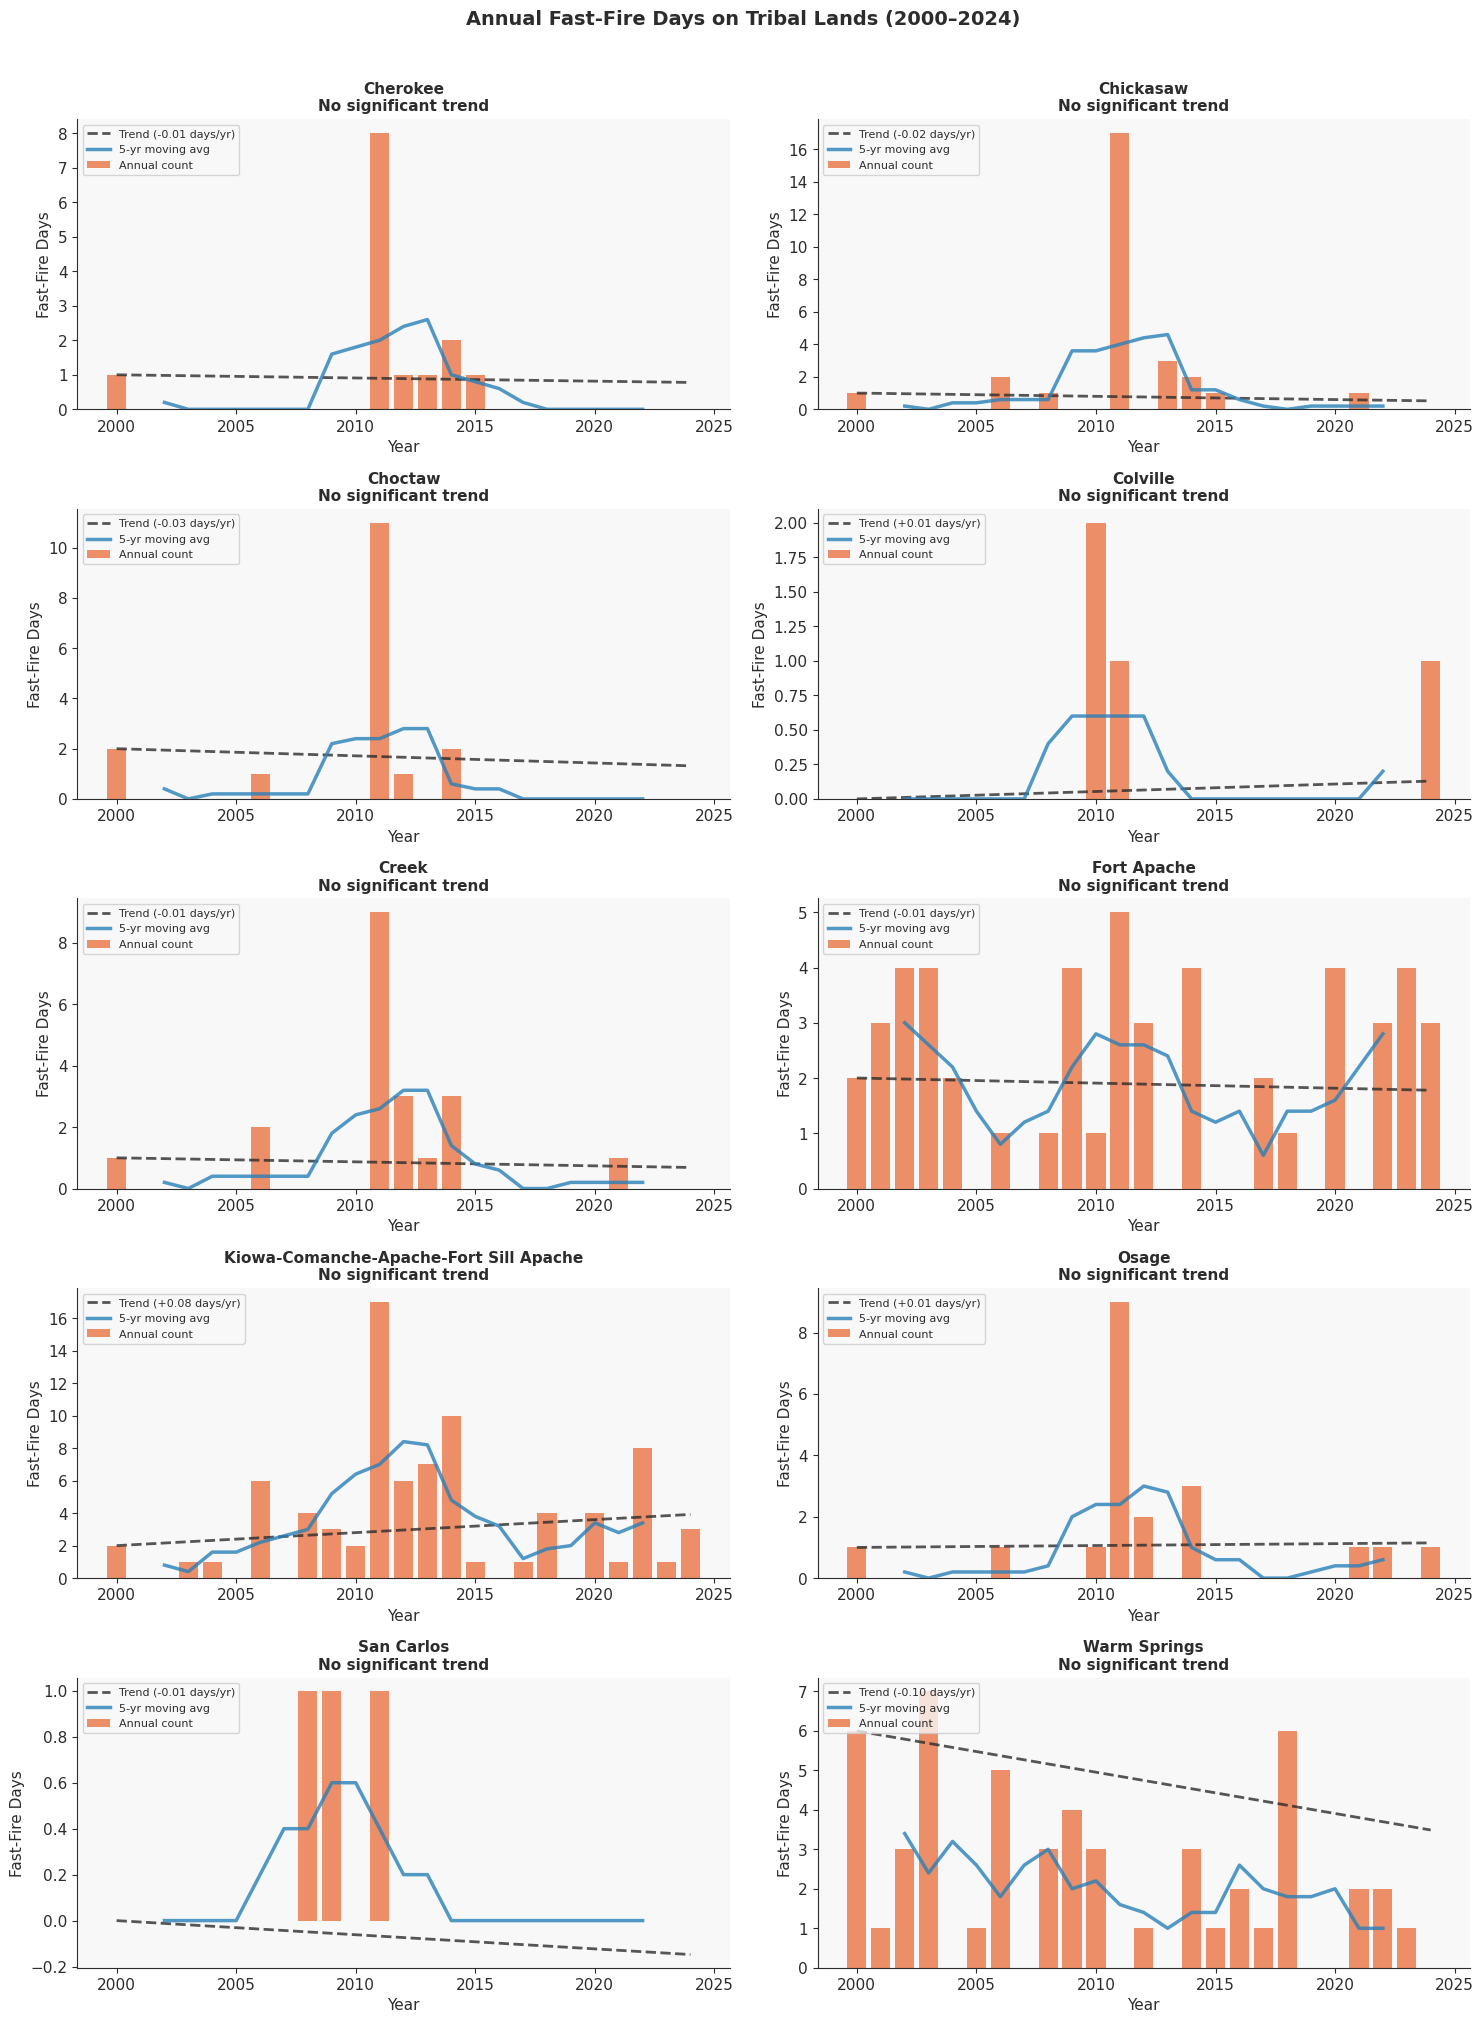

In [20]:
# Annual time series showing one subplot per Tribal land unit
tribe_names = annual_ff_days["tribal_name"].unique()
n_tribes    = len(tribe_names)
ncols = 2
nrows = (n_tribes + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, name in enumerate(tribe_names):
    ax   = axes[idx]
    sub  = annual_ff_days[annual_ff_days["tribal_name"] == name].sort_values("year")
    info = trend_analysis[trend_analysis["tribal_name"] == name].iloc[0]

    ax.bar(sub["year"], sub["ff_days"],
           color=styles.FIRE_ORANGE, alpha=0.7, width=0.8, label="Annual count")

    # Trend line
    yrs = sub["year"].values
    trend_line = info["slope_days_per_year"] * (yrs - yrs[0]) + sub["ff_days"].iloc[0]
    ax.plot(yrs, trend_line, linestyle="--", linewidth=2,
            color=styles.CHARCOAL, alpha=0.8,
            label=f"Trend ({info['slope_days_per_year']:+.2f} days/yr)")

    # 5-year moving average
    if len(sub) >= 5:
        ma = sub["ff_days"].rolling(5, center=True).mean()
        ax.plot(sub["year"], ma, linewidth=2.5,
                color=styles.SKY_BLUE, alpha=0.8, label="5-yr moving avg")

    sig = f"p = {info['p_value']:.3f}" if info["p_value"] < 0.05 else ""
    if sig:
        ax.text(0.98, 0.04, sig, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="#FFF9C4", alpha=0.8))

    ax.set_title(f"{name}\n{info['trend_direction']}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fast-Fire Days")
    ax.legend(fontsize=8, loc="upper left")
    sns.despine(ax=ax)

# Hide any unused axes
for ax in axes[n_tribes:]:
    ax.set_visible(False)

plt.suptitle(
    f"Annual Fast-Fire Days on Tribal Lands "
    f"({ANALYSIS_CONFIG['start_year']}–{ANALYSIS_CONFIG['end_year']})",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/fast_fire_days_trends.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\fast_fire_monthly_heatmap.png


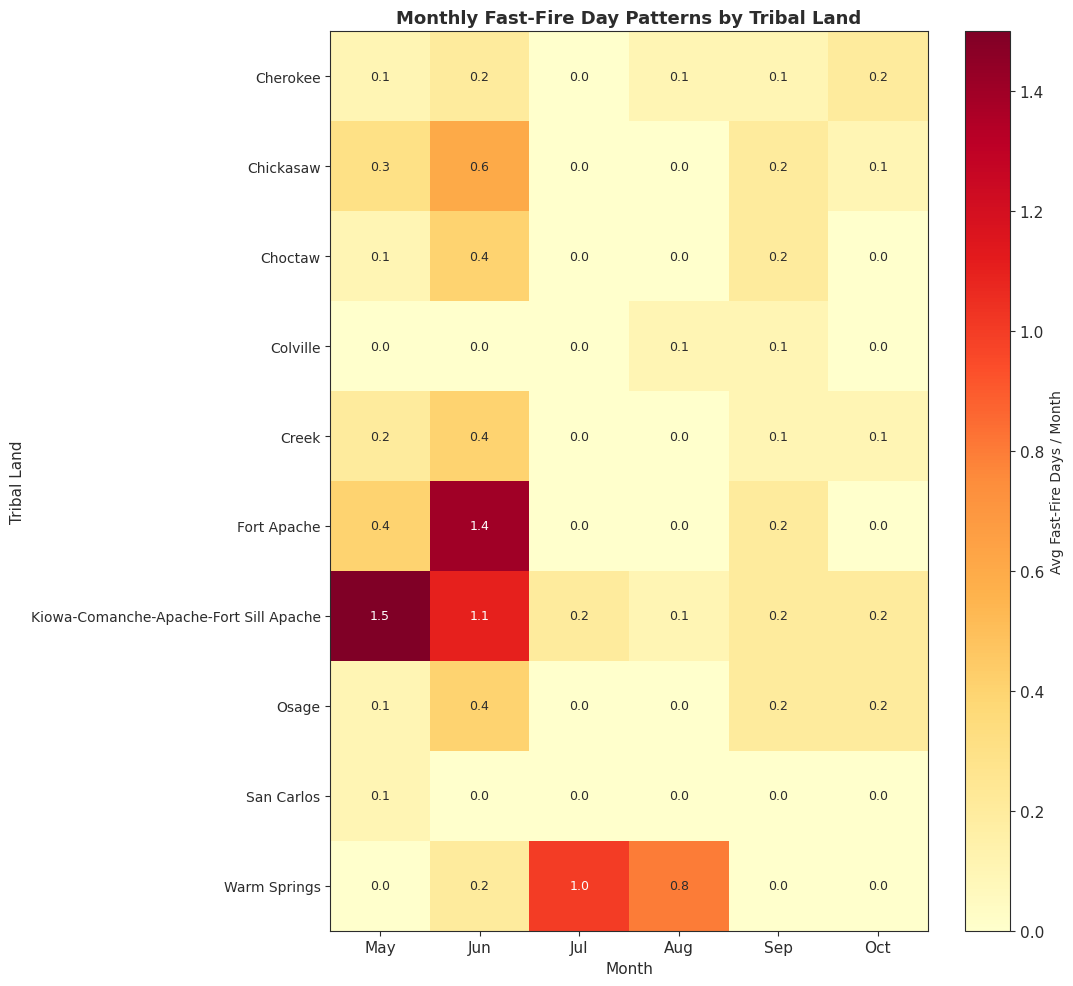

In [21]:
# Monthly heatmap 
fig, ax = plt.subplots(figsize=(11, max(4, n_tribes * 0.8 + 2)))

hm_data = monthly_pivot.fillna(0).values
im = ax.imshow(hm_data, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(monthly_pivot.columns)))
ax.set_yticks(range(len(monthly_pivot.index)))
ax.set_xticklabels(monthly_pivot.columns, fontsize=11)
ax.set_yticklabels(monthly_pivot.index, fontsize=10)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Avg Fast-Fire Days / Month", fontsize=10)

vmax = hm_data.max() if hm_data.max() > 0 else 1
for i in range(len(monthly_pivot.index)):
    for j in range(len(monthly_pivot.columns)):
        v = hm_data[i, j]
        color = "white" if v > vmax * 0.6 else styles.CHARCOAL
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color=color, fontsize=9)

ax.set_title("Monthly Fast-Fire Day Patterns by Tribal Land",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Tribal Land")
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/fast_fire_monthly_heatmap.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\fast_fire_period_comparison.png


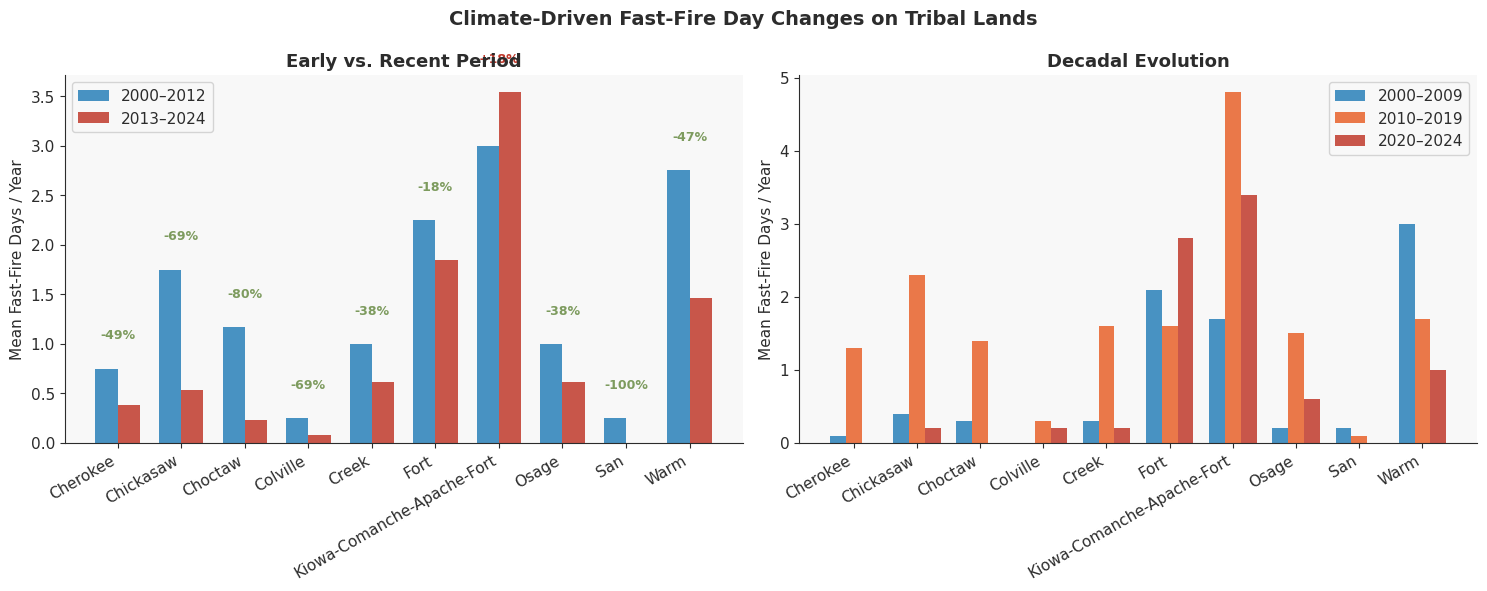

In [22]:
# Early vs. recent period comparison 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

early_means  = [trend_analysis.loc[trend_analysis["tribal_name"] == n, "early_period_mean"].iloc[0]  for n in tribe_names]
recent_means = [trend_analysis.loc[trend_analysis["tribal_name"] == n, "recent_period_mean"].iloc[0] for n in tribe_names]
short_names  = [n.split()[0] for n in tribe_names]

x = np.arange(len(tribe_names))
w = 0.35

axes[0].bar(x - w/2, early_means,  w, label=f"{ANALYSIS_CONFIG['start_year']}–2012",
            color=styles.SKY_BLUE,    alpha=0.85)
axes[0].bar(x + w/2, recent_means, w, label="2013–2024",
            color=styles.EMBER_RED,   alpha=0.85)

for i, (e, r) in enumerate(zip(early_means, recent_means)):
    if e > 0:
        pct = (r - e) / e * 100
        col = styles.EMBER_RED if pct > 0 else styles.SAGE_GREEN
        axes[0].text(i, max(e, r) + 0.3, f"{pct:+.0f}%",
                     ha="center", fontsize=9, color=col, fontweight="bold")

axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=30, ha="right")
axes[0].set_ylabel("Mean Fast-Fire Days / Year")
axes[0].set_title("Early vs. Recent Period", fontsize=13, fontweight="bold")
axes[0].legend()
sns.despine(ax=axes[0])

# Decadal comparison
decades = {
    "2000–2009": range(2000, 2010),
    "2010–2019": range(2010, 2020),
    "2020–2024": range(2020, 2025),
}
dec_colors = [styles.SKY_BLUE, styles.FIRE_ORANGE, styles.EMBER_RED]
bw = 0.25

for i, (decade, yrs) in enumerate(decades.items()):
    vals = [
        annual_ff_days[
            (annual_ff_days["tribal_name"] == n) &
            (annual_ff_days["year"].isin(yrs))
        ]["ff_days"].mean()
        for n in tribe_names
    ]
    axes[1].bar(x + (i - 1) * bw, vals, bw,
                label=decade, color=dec_colors[i], alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=30, ha="right")
axes[1].set_ylabel("Mean Fast-Fire Days / Year")
axes[1].set_title("Decadal Evolution", fontsize=13, fontweight="bold")
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle("Climate-Driven Fast-Fire Day Changes on Tribal Lands",
             fontsize=14, fontweight="bold")
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/fast_fire_period_comparison.png")
plt.show()

## Multi-Day Episode Analysis

In [23]:
def identify_fire_weather_episodes(
    df: pd.DataFrame,
    min_duration: int = 3,
) -> pd.DataFrame:
    """
    Identify runs of consecutive fast-fire days lasting >= min_duration days.
    Multi-day episodes are particularly dangerous because suppression resources
    cannot rest and fuels continue to dry.
    """
    episodes = []
    for name in df["tribal_name"].unique():
        sub = df[df["tribal_name"] == name].sort_values("date").copy()
        sub["grp"] = (sub["fast_fire_day"] != sub["fast_fire_day"].shift()).cumsum()

        for _, group in sub[sub["fast_fire_day"]].groupby("grp"):
            if len(group) >= min_duration:
                episodes.append({
                    "tribal_name":   name,
                    "start_date":    group["date"].min(),
                    "end_date":      group["date"].max(),
                    "duration_days": len(group),
                    "year":          group["year"].iloc[0],
                    "max_temp_f":    group["temp_max_f"].max(),
                    "min_rh_pct":    group["rh_min_pct"].min(),
                    "max_wind_mph":  group["wind_mph"].max(),
                    "max_bi":        group["burning_index"].max(),
                })

    return pd.DataFrame(episodes) if episodes else pd.DataFrame()


episodes = identify_fire_weather_episodes(fire_season_data, min_duration=3)

print(f"Multi-Day Fast-Fire Episodes (>= 3 consecutive days)")
if episodes.empty:
    print("No episodes of >= 3 consecutive days found.")
    print("Consider lowering min_duration or the threshold_level.")
else:
    print(f"Total episodes: {len(episodes)}")
    print("\nTop 10 longest:")
    print(
        episodes.nlargest(10, "duration_days")[
            ["tribal_name", "start_date", "duration_days", "max_temp_f", "min_rh_pct", "max_wind_mph"]
        ].to_string(index=False)
    )
    print("\nEpisode count by Tribal land:")
    print(episodes.groupby("tribal_name").size().sort_values(ascending=False).to_string())

Multi-Day Fast-Fire Episodes (>= 3 consecutive days)
Total episodes: 19

Top 10 longest:
                           tribal_name start_date  duration_days  max_temp_f  min_rh_pct  max_wind_mph
Kiowa-Comanche-Apache-Fort Sill Apache 2013-06-21              5      104.99        17.7     18.566602
                             Chickasaw 2011-06-17              4      111.29        12.5     25.501116
                               Choctaw 2011-06-17              4      109.13        19.0     26.843280
Kiowa-Comanche-Apache-Fort Sill Apache 2011-06-24              4      112.19         9.2     20.132460
                              Cherokee 2011-06-25              3      109.67        21.3     20.132460
                             Chickasaw 2011-05-28              3      104.27        22.3     24.158952
                             Chickasaw 2011-06-25              3      108.95        18.3     19.685072
                             Chickasaw 2013-06-23              3      104.09        18.

## Exports

In [24]:
# Export all analysis tables 
exports = {
    "annual_fast_fire_days.csv":     annual_ff_days,
    "fast_fire_trend_analysis.csv":  trend_analysis,
    "fast_fire_monthly_patterns.csv":monthly_patterns,
    "fast_fire_seasonal_shifts.csv": seasonal_shifts,
    "fast_fire_extreme_years.csv":   extreme_years,
}
if not episodes.empty:
    exports["fast_fire_episodes.csv"] = episodes

for fname, df in exports.items():
    path = constants.OUTPUTS_DIR / fname
    df.to_csv(path, index=False)
    print(f"Exported to {path.relative_to(REPO_ROOT)}")

Exported to outputs\annual_fast_fire_days.csv
Exported to outputs\fast_fire_trend_analysis.csv
Exported to outputs\fast_fire_monthly_patterns.csv
Exported to outputs\fast_fire_seasonal_shifts.csv
Exported to outputs\fast_fire_extreme_years.csv
Exported to outputs\fast_fire_episodes.csv


## Summary and Findings

*(Fill in after running with real gridMET data.)*

Questions to address in the narrative:
- Which Tribal lands show the highest annual fast-fire day counts, and has that changed?
- Are there statistically significant trends? If not, does that mean risk is stable
  or that variability is too high to detect a signal with 25 years of data?
- What are the policy implications? Fast-fire days are driven by weather, not fuel
  management, so this shifts the discussion from Tribal responsibility to climate
  vulnerability and the need for proportional federal support.
- What limitations apply? For example, gridMET is gridded/modeled data, not on-site measurements.
  For operational use, RAWS station data from specific Tribal lands would be preferable.

---
## References

In [25]:
print(generate_citations(["gridmet", "census_aiannh"])) 

References/Data Sources
----------------------------------------
- gridMET Daily Surface Meteorological Data. University of Idaho Climatology Lab. https://www.climatologylab.org/gridmet.html
- Census TIGER AIANNH. US Census Bureau. https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
